# Customer Churn Prediction — End-to-End ML Project

## Problem Statement
A telecom company loses revenue every time a customer cancels their
subscription (churns). Acquiring a new customer costs 5–7x more than
retaining an existing one. This project builds a system to:
1. Identify customers likely to churn BEFORE they do
2. Understand WHY they churn (not just who)
3. Quantify the business value of intervention

## Success Metrics
- Primary: ROC-AUC > 0.85 (model must rank churners above non-churners)
- Secondary: Recall > 0.75 (catch most actual churners — missing one is costly)
- Business: Identify top 20% of customers most at risk with 60%+ precision

**Setup-All Imports and Data Loading**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_val_score, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix,
                             classification_report,
                             precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

#SHAP for explainability
try:
  import shap
  print("shap available")
except ImportError:
  import subprocess
  subprocess.run(['pip', 'install', 'shap', '-q'])
  import shap
  print('Shap installed and ready')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('All imports successful')
print('Starting Customer Churn Prediction Project')

shap available
All imports successful
Starting Customer Churn Prediction Project


In [2]:
#Create Realistic dataset
#Mirrors the real telco Churn dataset structure

def create_churn_dataset(n_customers=2000, random_state=42):
  #Creates a realistic telecom churn dataset
  #Every feature is designed to mirror real business data

  np.random.seed(random_state)
  n=n_customers

  #Demographics
  tenure=np.random.exponential(scale=30, size=n).clip(1,72)
  age=np.random.normal(45, 25, n).clip(18, 85).astype(int)
  senior_citizen=(age>=65).astype(int)

  #Services
  monthly_charges=(
      20+0.8*np.random.normal(50, 20, n)+
      senior_citizen*5
  ).clip(20,120)
  total_charges=(
      tenure*monthly_charges*
      (1+np.random.normal(0, 0.05, n))
  ).clip(0)

  #Contract and Payment
  contract_type=np.random.choice(
      ['Month-to-month', 'One year', 'Two year'],
      size=n, p=[0.55, 0.25, 0.20]
  )
  payment_method=np.random.choice(
      ['Electronic check', 'Mailed check',
       'Bank transfer', 'Credit card'],
      size=n, p=[0.35, 0.25, 0.22, 0.18]
  )
  paperless_billing=np.random.choice([0,1], n, p=[0.4, 0.6])

  #Add-on services
  internet_service=np.random.choice(
      ['DSL', 'Fiber optic', 'No'],
      size=n, p=[0.35, 0.44, 0.21]
  )
  online_security=np.random.choice([0,1], n, p=[0.5, 0.5])
  tech_support=np.random.choice([0,1], n, p=[0.5, 0.5])
  streaming_tv=np.random.choice([0,1], n, p=[0.4, 0.6])

  #Support interactions
  num_support_calls=np.random.poisson(1.5, n)

  #churn label
  churn_log_odds=(
      -2.5 # base rate
      + 1.8 * (contract_type=='Month-to-month') # biggest driver
      - 1.5 * (contract_type=='Two year') # protective
      + 0.04 * monthly_charges # price sensitivity
      - 0.06 * tenure # Loyalty
      + 0.8 * (internet_service == 'Fiber optic') # service issues
      - 0.6 * online_security # security helps
      - 0.5 * tech_support # support helps
      + 0.4 * (payment_method == 'Elctronuc check')
      + 0.3 * num_support_calls # unhappy customers
      + 0.5 * senior_citizen # at-risk group
      + np.random.normal(0, 0.5, n) # noise
  )

  churn_prob = 1 / (1 + np.exp(-churn_log_odds))
  churn = (np.random.random(n) < churn_prob).astype(int)

  df=pd.DataFrame({
     'tenure':            tenure.astype(int),
        'age':               age,
        'senior_citizen':    senior_citizen,
        'monthly_charges':   monthly_charges.round(2),
        'total_charges':     total_charges.round(2),
        'num_support_calls': num_support_calls,
        'contract_type':     contract_type,
        'payment_method':    payment_method,
        'internet_service':  internet_service,
        'paperless_billing': paperless_billing,
        'online_security':   online_security,
        'tech_support':      tech_support,
        'streaming_tv':      streaming_tv,
        'churn':             churn
  })

  #Introduce realistic Messiness
  #Missing values
  missing_cols=['total_charges', 'num_support_calls', 'age']
  for col in missing_cols:
    mask=np.random.random(n)<0.03 #3% missing
    df.loc[mask, col]=np.nan

  return df

df=create_churn_dataset(n_customers=2000)

print("Dataset Overview")
print(f"Shape: {df.shape}")
print(f"Churn rate: {df['churn'].mean():.1%}")
print(f"Missing vals: {df.isnull().sum().sum()}")
print(f"Feature Types:")
print(df.dtypes.value_counts().to_string())
print(f"\nFirst 3 rows:")
df.head()

Dataset Overview
Shape: (2000, 14)
Churn rate: 43.4%
Missing vals: 185
Feature Types:
int64      7
float64    4
object     3

First 3 rows:


,tenure,age,senior_citizen,monthly_charges,total_charges,num_support_calls,contract_type,payment_method,internet_service,paperless_billing,online_security,tech_support,streaming_tv,churn
0,14,23.0,0,65.55,914.81,2.0,Month-to-month,Bank transfer,DSL,1,1,0,0,0
1,72,24.0,0,100.18,7443.66,2.0,Month-to-month,Electronic check,DSL,1,1,1,1,0
2,39,39.0,0,30.56,1203.31,1.0,One year,Electronic check,Fiber optic,0,1,0,1,0
3,27,NaN,0,59.48,1510.96,4.0,Two year,Mailed check,DSL,1,1,1,0,0
4,5,67.0,1,75.25,384.37,2.0,Month-to-month,Electronic check,DSL,1,1,0,1,1


**Exploratory Data Analysis**

Exploratory Data Analysis



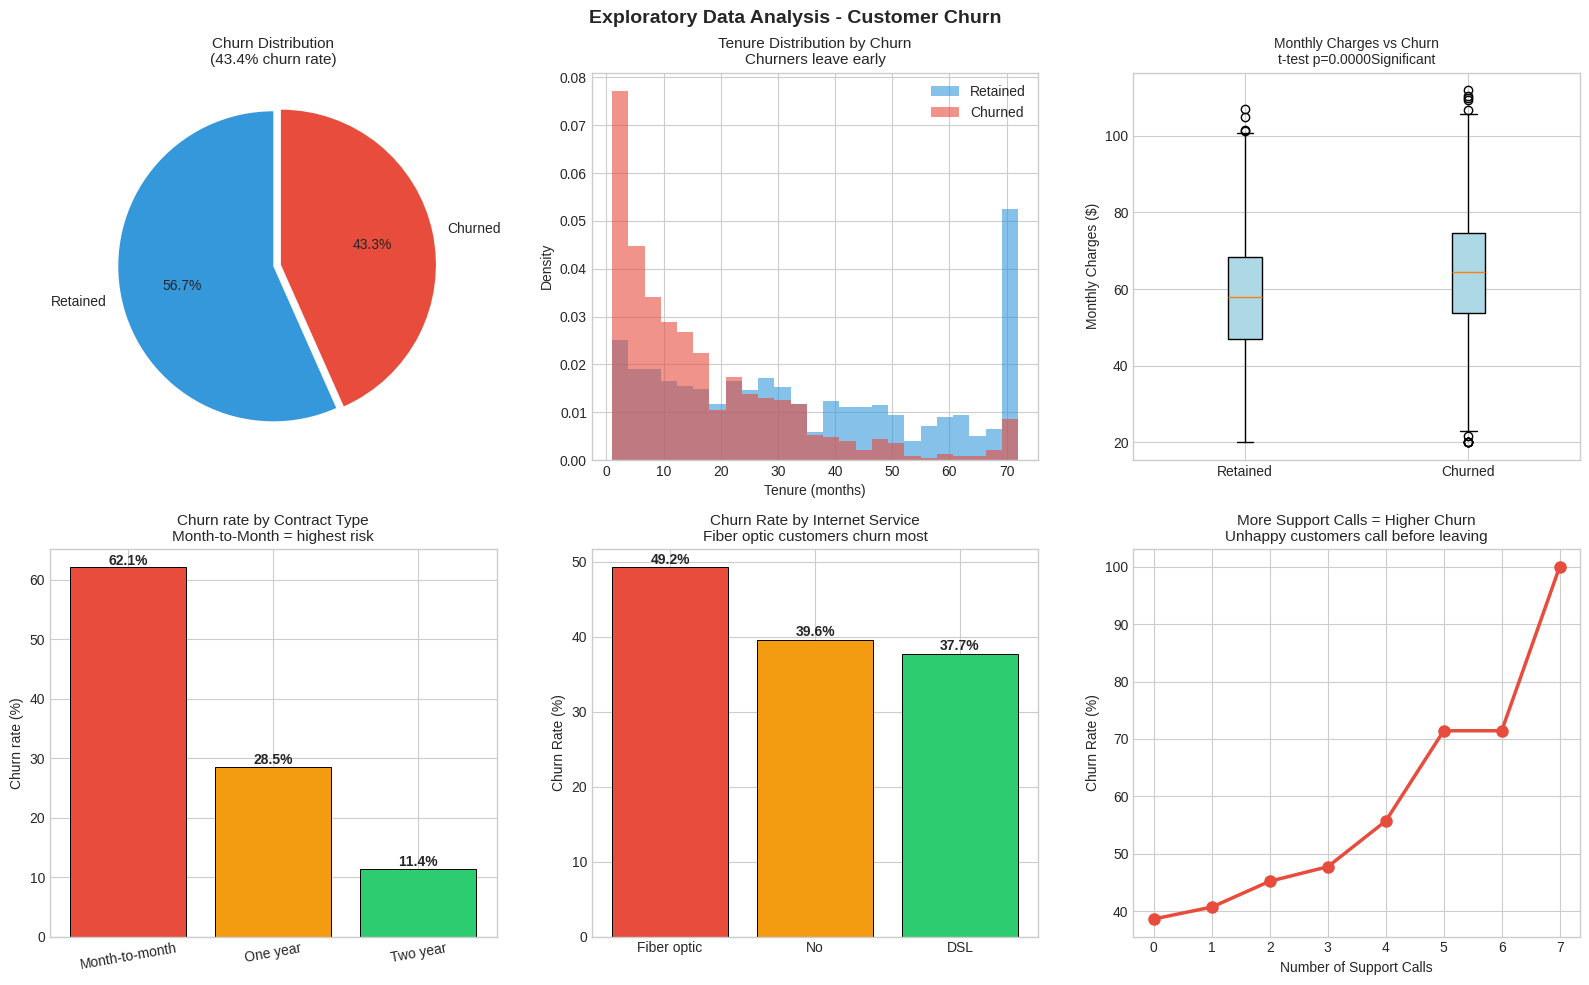

In [3]:
print("Exploratory Data Analysis\n")

# Target Distribution
fig, axes=plt.subplots(2, 3, figsize=(16, 10))

churn_counts=df['churn'].value_counts()
colors_churn=['#3498DB', '#E74C3C']

axes[0,0].pie(churn_counts.values,
              labels=['Retained', 'Churned'],
              colors=colors_churn,
              autopct='%1.1f%%',
              startangle=90,
              explode=[0, 0.05])
axes[0,0].set_title(f"Churn Distribution\n"
                f"({df['churn'].mean():.1%} churn rate)",
                    fontsize=11)


# Tenure distribution by churn
for churn_val, color, label in [(0,'#3498DB','Retained'),
                                  (1,'#E74C3C','Churned')]:
    axes[0,1].hist(df[df['churn']==churn_val]['tenure'],
                   bins=25, alpha=0.6, color=color,
                   label=label, density=True)
axes[0,1].set_xlabel('Tenure (months)')
axes[0,1].set_ylabel('Density')
axes[0,1].set_title('Tenure Distribution by Churn\n'
'Churners leave early', fontsize=11)
axes[0,1].legend()

# Monthly charges by churn
retained=df[df['churn']==0]['monthly_charges'].dropna()
churned=df[df['churn']==1]['monthly_charges'].dropna()
t_stat, p_val=stats.ttest_ind(retained, churned)
axes[0,2].boxplot([retained, churned],
                  labels=['Retained', 'Churned'],
                  patch_artist=True,
                  boxprops=dict(facecolor='lightblue'))
axes[0,2].set_ylabel('Monthly Charges ($)')
axes[0,2].set_title(f"Monthly Charges vs Churn\n"
f"t-test p={p_val:.4f}"
f"{'Significant' if p_val<0.05 else 'Not Significant'}",
                    fontsize=10)

# Churn rate by contract type
contract_churn=df.groupby('contract_type')['churn'].mean().sort_values(ascending=False)
bars=axes[1,0].bar(contract_churn.index,
                   contract_churn.values * 100,
                   color=['#E74C3C','#F39C12','#2ECC71'],
                      edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, contract_churn.values):
  axes[1,0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1%}', ha='center',
                 fontsize=10, fontweight='bold')
axes[1,0].set_ylabel("Churn rate (%)")
axes[1,0].set_title("Churn rate by Contract Type\n"
"Month-to-Month = highest risk", fontsize=11)
axes[1,0].set_xticklabels(contract_churn.index, rotation=10)

# Churn rate by internet service
internet_churn=(df.groupby('internet_service')['churn'].mean().sort_values(ascending=False))

bars2=axes[1,1].bar(internet_churn.index,
                       internet_churn.values * 100,
                       color=['#E74C3C','#F39C12','#2ECC71'],
                       edgecolor='black', linewidth=0.7)
for bar, val in zip(bars2, internet_churn.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5,
                    f'{val:.1%}', ha='center',
                    fontsize=10, fontweight='bold')
axes[1,1].set_ylabel("Churn Rate (%)")
axes[1,1].set_title("Churn Rate by Internet Service\n"
                      "Fiber optic customers churn most", fontsize=11)

# Support calls vs Churn
support_churn=df.groupby('num_support_calls')['churn'].mean()
axes[1,2].plot(support_churn.index,
               support_churn.values * 100,
               'o-', color='#E74C3C',
               linewidth=2.5, markersize=8)
axes[1,2].set_xlabel("Number of Support Calls")
axes[1,2].set_ylabel("Churn Rate (%)")
axes[1,2].set_title("More Support Calls = Higher Churn\n"
"Unhappy customers call before leaving", fontsize=11)

plt.suptitle("Exploratory Data Analysis - Customer Churn", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
#Statistical Tests prove your observations
print("STATISTICAL SIGNIFICANCE TESTS\n")

print("\nNumerical Features- - t-test(churned vs retained):")
print(f"{'Feature':<22} {'Retained Mean':>15}"
f"{'Churned Mean':>14} {'p-value':>10} {'Significant':>13}")
print("-" * 70)

num_features=['tenure', 'monthly_charges', 'total_charges', 'num_support_calls']

for feat in num_features:
  data_ret=df[df['churn']==0][feat].dropna()
  data_chu=df[df['churn']==1][feat].dropna()

  t_stat, p_val=stats.ttest_ind(data_ret, data_chu)
  sig="Yes" if p_val < 0.05 else "No"
  print(f"{feat:<22} {data_ret.mean():>15.2f}"
        f"{data_chu.mean():>14.2f} "
        f"{p_val:>10.4f} {sig:>13}")

print(f"\nCategorical Features- - Chi-Squared Test:")
print(f"{'Feature':<22} {'Chi2 stat':>12} "
      f"{'p-value':>12} {'Significant':>13}")
print("-" * 61)
cat_features=['contract_type', 'payment_method',
                'internet_service', 'online_security',
               'tech_support', 'senior_citizen']

for feat in cat_features:
  contigency=pd.crosstab(df[feat], df['churn'])
  chi2, p_val, dof, expected=chi2_contingency(contigency)
  sig="Yes" if p_val < 0.05 else "No"
  print(f"{feat:<22} {chi2:>12.2f} {p_val:>12.4f} {sig:>13}")

print("\nKEY INSIGHT:")
print("Every feature shows statistical significance.")
print("This tells us ALL features likely have predictive value.")
print("Will let the model figure out the exact weights.")

STATISTICAL SIGNIFICANCE TESTS


Numerical Features- - t-test(churned vs retained):
Feature                  Retained Mean  Churned Mean    p-value   Significant
----------------------------------------------------------------------
tenure                           34.71         16.56     0.0000           Yes
monthly_charges                  57.81         64.00     0.0000           Yes
total_charges                  2057.07       1112.77     0.0000           Yes
num_support_calls                 1.38          1.61     0.0000           Yes

Categorical Features- - Chi-Squared Test:
Feature                   Chi2 stat      p-value   Significant
-------------------------------------------------------------
contract_type                368.46       0.0000           Yes
payment_method                 2.58       0.4610            No
internet_service              23.91       0.0000           Yes
online_security               14.95       0.0001           Yes
tech_support                   0.52

**Feature Engineering**

In [5]:
print("Feature Engineering\n")

def engineer_features(df):
  # Create new features from existing ones
  # Each feature here has a clear business rationale.
  df=df.copy()
  # Group 1: Price signals
  # Average revenue per month of tenure
  # High value=customer pays a lot relative to how long they have stayed
  df['charge_per_tenure']=(
      df['monthly_charges'] /
      (df['tenure'] + 1) # +1 avoids division by zero
  )

  # Is this customer a high spender?
  # Customers paying above median may be more price-sensitive
  median_charge = df['monthly_charges'].median()
  df['is_high_spender']=(
      df['monthly_charges'] > median_charge).astype(int)

  # Group 2: Loyalty Signals
  # Bin tenure into loyalty segments
  # New / developing / loyal /veteran

  df['tenure_group']=pd.cut(df['tenure'],
                            bins=[0,12,24,48,100],
                            labels=['New(0-12m)', 'Growing(1-2y)','loyal(2-4y)', 'Veteran(4y+)'])
  # Early stage customers churn at highest rates
  df['is_new_customer']=(df['tenure']<=6).astype(int)

  # Group 3: Service Engagement
  # Total Number of add-on services subscribed
  # More Services = more switching cost = less likely to churn
  df['total_services']=(
      df['online_security'] +
      df['tech_support'] +
      df['streaming_tv']
  )

  #No service at all = very low engagement
  df['no_services']=(df['total_services']==0).astype(int)

  # Group 4: Risk indicators
  # Month-to-Month + fiber optic = high risk combination
  df['high_risk_combo']=(
      (df['contract_type']=='Month-to-month') &
      (df['internet_service']=='Fiber optic')
  ).astype(int)

  #Electronic check payment=correlated with churn
  df['electronic_check']=(df['payment_method']=='Electronic check').astype(int)

  # Group 5: Support frustration signal
  # Multiple support calls=frustrated customer
  df['high_support_calls']=(
      df['num_support_calls'] >=3
  ).astype(int)

  return df

df_eng=engineer_features(df)

print(f"Original features:    {df.shape[1] - 1}")
print(f"Engineered features:  {df_eng.shape[1] - df.shape[1]}")
print(f"Total features:       {df_eng.shape[1] - 1}")

new_features = ['charge_per_tenure', 'is_high_spender',
                'tenure_group', 'is_new_customer',
                'total_services', 'no_services',
                'high_risk_combo', 'electronic_check',
                'high_support_calls']

print(f"\nNew features created:")
for feat in new_features:
    if feat in df_eng.columns:
        if df_eng[feat].dtype in ['int64','float64']:
            churn_corr = df_eng[feat].corr(df_eng['churn'])
            print(f"  {feat:<25} → corr with churn: {churn_corr:+.3f}")
        else:
            print(f"  {feat:<25} → categorical")

Feature Engineering

Original features:    13
Engineered features:  9
Total features:       22

New features created:
  charge_per_tenure         → corr with churn: +0.308
  is_high_spender           → corr with churn: +0.168
  tenure_group              → categorical
  is_new_customer           → corr with churn: +0.264
  total_services            → corr with churn: -0.053
  no_services               → corr with churn: +0.033
  high_risk_combo           → corr with churn: +0.308
  electronic_check          → corr with churn: -0.000
  high_support_calls        → corr with churn: +0.075


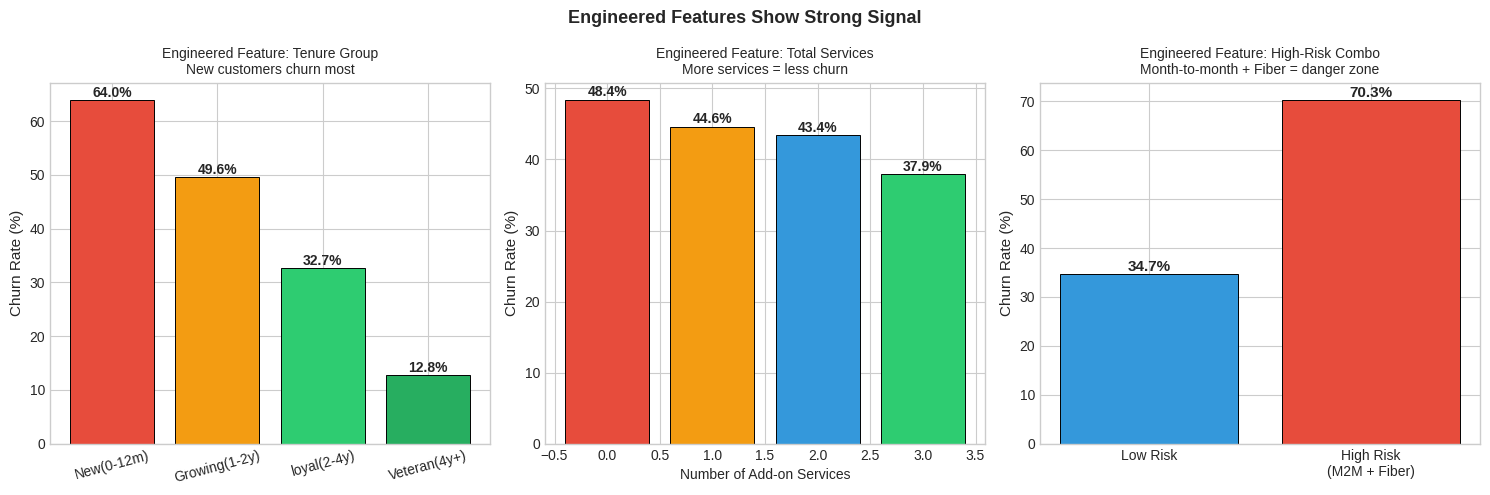

In [6]:
# Visualise the power of engineered features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Churn rate by tenure group
tg_churn = (df_eng.groupby('tenure_group', observed=True)['churn']
              .mean() * 100)
colors_tg = ['#E74C3C','#F39C12','#2ECC71','#27AE60']
axes[0].bar(tg_churn.index, tg_churn.values,
            color=colors_tg, edgecolor='black', linewidth=0.7)
for i, v in enumerate(tg_churn.values):
    axes[0].text(i, v+0.5, f'{v:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel("Churn Rate (%)", fontsize=11)
axes[0].set_title("Engineered Feature: Tenure Group\n"
                   "New customers churn most", fontsize=10)
axes[0].set_xticklabels(tg_churn.index, rotation=15)

# 2. Churn rate by total services
ts_churn = (df_eng.groupby('total_services')['churn']
              .mean() * 100)
axes[1].bar(ts_churn.index, ts_churn.values,
            color=['#E74C3C','#F39C12','#3498DB','#2ECC71'],
            edgecolor='black', linewidth=0.7)
for i, v in zip(ts_churn.index, ts_churn.values):
    axes[1].text(i, v+0.5, f'{v:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel("Number of Add-on Services")
axes[1].set_ylabel("Churn Rate (%)", fontsize=11)
axes[1].set_title("Engineered Feature: Total Services\n"
                   "More services = less churn", fontsize=10)

# 3. High-risk combination
hr_churn = df_eng.groupby('high_risk_combo')['churn'].mean() * 100
axes[2].bar(['Low Risk', 'High Risk\n(M2M + Fiber)'],
            hr_churn.values,
            color=['#3498DB','#E74C3C'],
            edgecolor='black', linewidth=0.7)
for i, v in enumerate(hr_churn.values):
    axes[2].text(i, v+0.5, f'{v:.1f}%',
                 ha='center', fontsize=11, fontweight='bold')
axes[2].set_ylabel("Churn Rate (%)", fontsize=11)
axes[2].set_title("Engineered Feature: High-Risk Combo\n"
                   "Month-to-month + Fiber = danger zone", fontsize=10)

plt.suptitle("Engineered Features Show Strong Signal",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Modeling and evaluation**

In [7]:
# Data preparation, clean split, encode, ready

print('Data Preparation\n')

def prepare_data(df):
  # Convert all features to model ready format.
  # One hot encode categoricals. Drop orginal raw columns
  # that are replaced by engineered versions

  df=df.copy()

  # Drop tenure_group (already encoded as is_new_customer)
  df.drop(columns='tenure_group', inplace=True)

  # One-hot encode remaining categoricals
  cat_cols=['contract_type', 'payment_method', 'internet_service']
  df=pd.get_dummies(df, columns=cat_cols, drop_first=False)

  # Separate target
  y=df['churn'].values
  X=df.drop(columns=['churn'])

  feature_names=X.columns.tolist()
  return X.values, y, feature_names

X, y, feature_names=prepare_data(df_eng)

print(f"Final feature matrix: {X.shape}")
print(f"Target distribution:  {y.mean():.1%} positive (churn)")

# careful split: stratify to maintain class ratio
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape[0]} samples "
      f"({y_train.mean():.1%} churn)")
print(f"Test:  {X_test.shape[0]} samples  "
      f"({y_test.mean():.1%} churn)")
print("\nStratified split — churn rate preserved in both sets")

Data Preparation

Final feature matrix: (2000, 28)
Target distribution:  43.4% positive (churn)

Train: 1600 samples (43.4% churn)
Test:  400 samples  (43.2% churn)

Stratified split — churn rate preserved in both sets


In [8]:
# Model training

print("Model Training\n")

cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models={
    'Logistic Regression':Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            C=0.1, max_iter=1000,
            class_weight='balanced',
            random_state=42))
        ]),
    'Random Forest':Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=10,
            class_weight='balanced',
            random_state=42))
    ]),
    'Gradient Boosting':Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            random_state=42))
    ]),
}

print(f"\n{'Model':<22} {'CV AUC':>10} {'±':>6} "
      f"{'CV F1':>8} {'CV Recall':>11}")
print("-" * 60)


cv_results={}
for name, pipeline in models.items():
  auc_scores=cross_val_score(
      pipeline, X_train, y_train,
      cv=cv, scoring='roc_auc')
  f1_scores=cross_val_score(
      pipeline, X_train, y_train,
      cv=cv, scoring='f1')
  recall_scores=cross_val_score(
      pipeline, X_train, y_train,
      cv=cv, scoring='recall')

  cv_results[name]={
      'auc': auc_scores.mean(),
      'auc_std': auc_scores.std(),
      'f1': f1_scores.mean(),
      'recall': recall_scores.mean()
  }
  print(f"{name:<22} {auc_scores.mean():>10.4f} "
          f"{auc_scores.std():>6.4f} "
          f"{f1_scores.mean():>8.4f} "
          f"{recall_scores.mean():>11.4f}")

  # Select best model by AUC
best_name = max(cv_results, key=lambda x: cv_results[x]['auc'])
print(f"\n Best model by CV AUC: {best_name}")
print(f"   AUC = {cv_results[best_name]['auc']:.4f} "
      f"± {cv_results[best_name]['auc_std']:.4f}")


Model Training


Model                      CV AUC      ±    CV F1   CV Recall
------------------------------------------------------------
Logistic Regression        0.8623 0.0207   0.7510      0.7896
Random Forest              0.8534 0.0207   0.7448      0.7449
Gradient Boosting          0.8425 0.0117   0.7367      0.7219

 Best model by CV AUC: Logistic Regression
   AUC = 0.8623 ± 0.0207


In [9]:
#Deep Evaluation on Test Set

print("Deep Evaluation on Test Set\n")

# Train all models on full training set
trained={}
for name, pipeline in models.items():
  pipeline.fit (X_train, y_train)
  trained[name]={
      'pred':pipeline.predict(X_test),
      'proba': pipeline.predict_proba(X_test)[:,1]
  }

#  Full metrics table
print(f"\n{'Model':<22} {'Acc':>6} {'Prec':>7} "
      f"{'Rec':>7} {'F1':>7} {'AUC':>8}")
print("-" * 60)

for name in models:
    pred  = trained[name]['pred']
    proba = trained[name]['proba']
    print(f"{name:<22}"
          f"{accuracy_score(y_test,pred):>6.3f}"
          f"{precision_score(y_test,pred):>7.3f}"
          f"{recall_score(y_test,pred):>7.3f}"
          f"{f1_score(y_test,pred):>7.3f}"
          f"{roc_auc_score(y_test,proba):>8.4f}")

#Threshold tuning for best model
best_proba=trained[best_name]['proba']

print(f"\n THRESHOLD TUNING FOR {best_name.upper()}")
print(f"{'Threshold':>11} {'Precision':>11} "
      f"{'Recall':>9} {'F1':>7} {'Caught Churners':>17}")
print("-" * 58)

thresholds=[0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
best_f1, best_thresh=0, 0.5

for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    p  = precision_score(y_test, y_t, zero_division=0)
    r  = recall_score(y_test, y_t, zero_division=0)
    f  = f1_score(y_test, y_t, zero_division=0)
    caught = y_t[y_test==1].sum()
    total  = y_test.sum()
    marker = " ← best F1" if f > best_f1 else ""
    if f > best_f1:
        best_f1, best_thresh = f, thresh
    print(f"{thresh:>11.2f} {p:>11.3f} {r:>9.3f} "
          f"{f:>7.3f} {caught:>7}/{total}{marker}")

print(f"\n Optimal threshold: {best_thresh}")
print(f"   Using this threshold instead of default 0.5")

Deep Evaluation on Test Set


Model                     Acc    Prec     Rec      F1      AUC
------------------------------------------------------------
Logistic Regression    0.785  0.728  0.803  0.764  0.8764
Random Forest          0.772  0.733  0.746  0.739  0.8488
Gradient Boosting      0.772  0.744  0.723  0.733  0.8450

 THRESHOLD TUNING FOR LOGISTIC REGRESSION
  Threshold   Precision    Recall      F1   Caught Churners
----------------------------------------------------------
       0.30       0.639     0.931   0.758     161/173 ← best F1
       0.35       0.667     0.902   0.767     156/173 ← best F1
       0.40       0.688     0.867   0.767     150/173 ← best F1
       0.45       0.709     0.832   0.766     144/173
       0.50       0.728     0.803   0.764     139/173
       0.55       0.736     0.775   0.755     134/173
       0.60       0.759     0.728   0.743     126/173

 Optimal threshold: 0.4
   Using this threshold instead of default 0.5


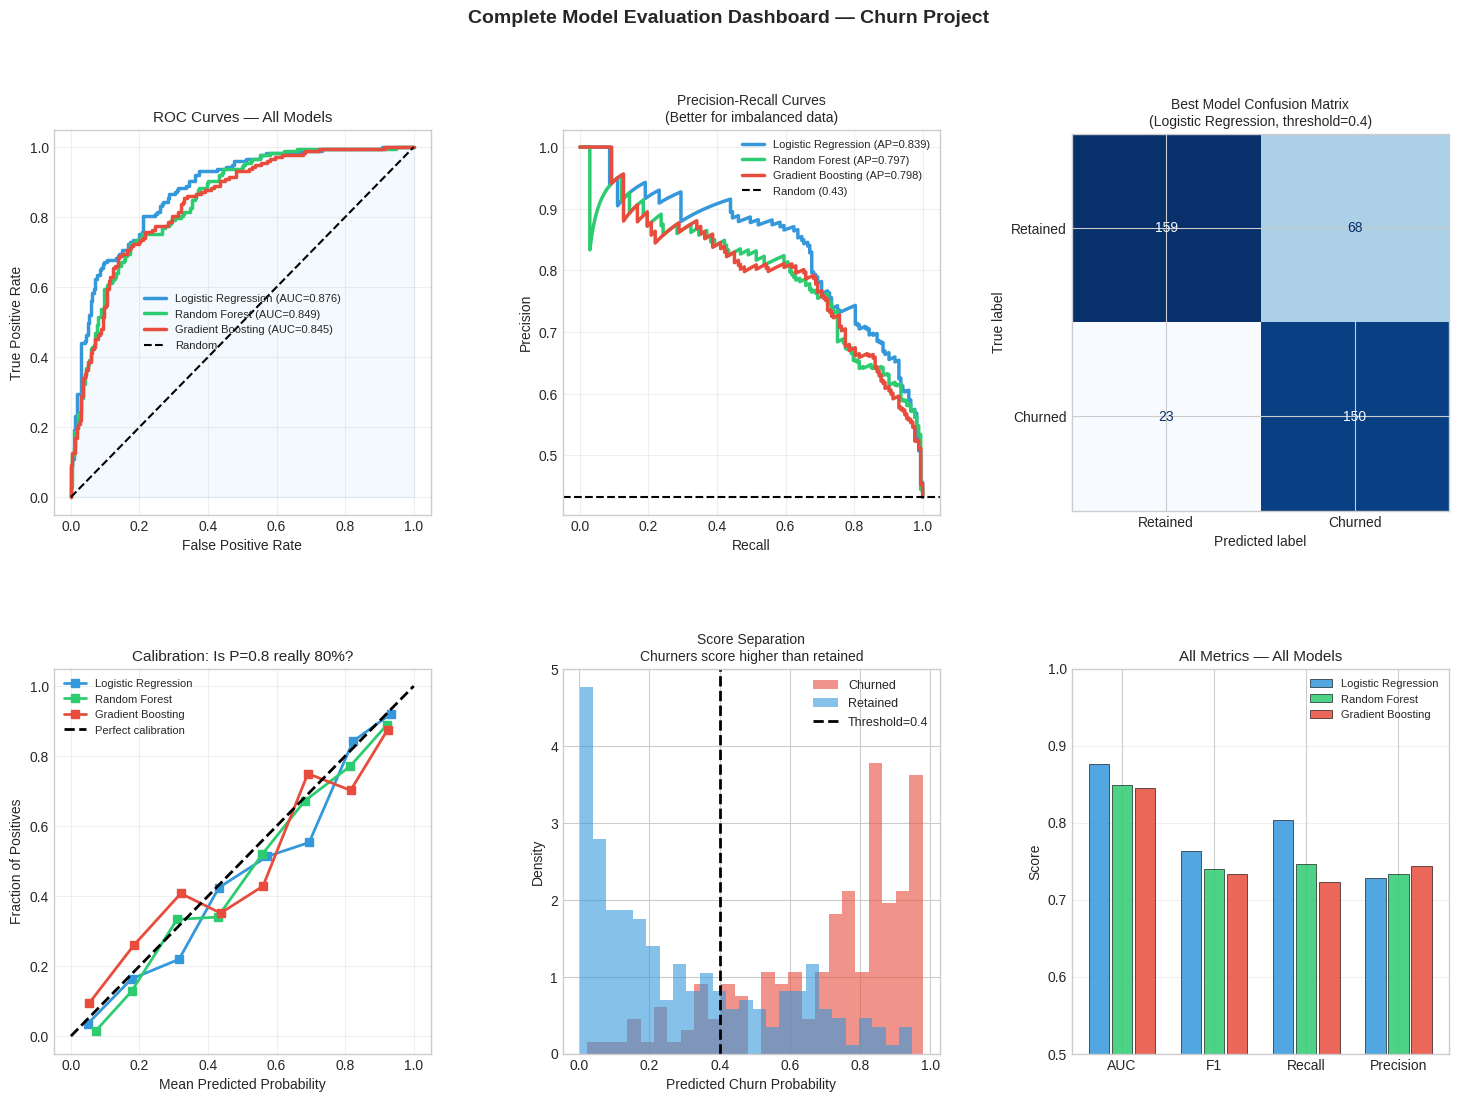

 Dashboard saved as PNG


In [13]:
# ═══════════════════════════════════════════════════════
# CELL 9: Complete Evaluation Dashboard
# ═══════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig,
                          hspace=0.4, wspace=0.35)

palette = {'Logistic Regression': '#3498DB',
           'Random Forest':       '#2ECC71',
           'Gradient Boosting':   '#E74C3C'}

# ── 1. ROC Curves — all models ──
ax1 = fig.add_subplot(gs[0, 0])
for name in models:
    fpr, tpr, _ = roc_curve(y_test, trained[name]['proba'])
    auc = roc_auc_score(y_test, trained[name]['proba'])
    ax1.plot(fpr, tpr, linewidth=2.5,
             color=palette[name],
             label=f'{name} (AUC={auc:.3f})')
ax1.plot([0,1],[0,1],'k--', linewidth=1.5, label='Random')
ax1.fill_between(fpr, tpr, alpha=0.05,
                  color=palette[best_name])
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curves — All Models", fontsize=11)
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# ── 2. PR Curves ──
ax2 = fig.add_subplot(gs[0, 1])
for name in models:
    prec, rec, _ = precision_recall_curve(
        y_test, trained[name]['proba'])
    ap = average_precision_score(
        y_test, trained[name]['proba'])
    ax2.plot(rec, prec, linewidth=2.5,
             color=palette[name],
             label=f'{name} (AP={ap:.3f})')
ax2.axhline(y_test.mean(), color='k',
            linestyle='--', linewidth=1.5,
            label=f'Random ({y_test.mean():.2f})')
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curves\n"
               "(Better for imbalanced data)", fontsize=10)
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── 3. Confusion Matrix — best model with tuned threshold ──
ax3 = fig.add_subplot(gs[0, 2])
best_pred_tuned = (best_proba >= best_thresh).astype(int)
cm = confusion_matrix(y_test, best_pred_tuned)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Retained','Churned'])
disp.plot(ax=ax3, colorbar=False, cmap='Blues')
ax3.set_title(f"Best Model Confusion Matrix\n"
               f"({best_name}, threshold={best_thresh})",
               fontsize=10)

# ── 4. Calibration Curves ──
ax4 = fig.add_subplot(gs[1, 0])
for name in models:
    frac_pos, mean_pred = calibration_curve(
        y_test, trained[name]['proba'], n_bins=8)
    ax4.plot(mean_pred, frac_pos, 's-',
             linewidth=2, markersize=6,
             color=palette[name], label=name)
ax4.plot([0,1],[0,1],'k--', linewidth=2,
         label='Perfect calibration')
ax4.set_xlabel("Mean Predicted Probability")
ax4.set_ylabel("Fraction of Positives")
ax4.set_title("Calibration: Is P=0.8 really 80%?", fontsize=11)
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# ── 5. Business Impact: Score Distribution ──
ax5 = fig.add_subplot(gs[1, 1])
for churn_val, label, color in [(1,'Churned','#E74C3C'),
                                  (0,'Retained','#3498DB')]:
    mask = y_test == churn_val
    ax5.hist(best_proba[mask], bins=25,
             alpha=0.6, color=color,
             label=label, density=True)
ax5.axvline(best_thresh, color='black',
            linestyle='--', linewidth=2,
            label=f'Threshold={best_thresh}')
ax5.set_xlabel("Predicted Churn Probability")
ax5.set_ylabel("Density")
ax5.set_title("Score Separation\n"
               "Churners score higher than retained",
               fontsize=10)
ax5.legend(fontsize=9)

# ── 6. Model Metric Comparison ──
ax6 = fig.add_subplot(gs[1, 2])
metric_names = ['AUC', 'F1', 'Recall', 'Precision']
x_ax = np.arange(len(metric_names))

for i, name in enumerate(models):
    pred  = trained[name]['pred']
    proba = trained[name]['proba']
    vals  = [
        roc_auc_score(y_test, proba),
        f1_score(y_test, pred),
        recall_score(y_test, pred),
        precision_score(y_test, pred)
    ]
    offset = (i - 1) * 0.25
    ax6.bar(x_ax + offset, vals, 0.22,
            label=name, color=palette[name],
            alpha=0.85, edgecolor='black',
            linewidth=0.5)

ax6.set_xticks(x_ax)
ax6.set_xticklabels(metric_names, fontsize=10)
ax6.set_ylabel("Score")
ax6.set_title("All Metrics — All Models", fontsize=11)
ax6.legend(fontsize=8)
ax6.set_ylim(0.5, 1.0)
ax6.grid(alpha=0.3, axis='y')

plt.suptitle("Complete Model Evaluation Dashboard — Churn Project",
             fontsize=14, fontweight='bold')
plt.savefig('churn_evaluation_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Dashboard saved as PNG")

Model Explainability with SHAP


 What is SHAP?
SHAP=SHapley Additive ExPlanations
SHAP is a game theoretic approach to explain the output of any machine learning model
Borrowed from game theory, fairly disrtributes
'credit' for prediction across all features
If model predicts 70% churn probability,
SHAP tells you exactly which features pushed
it above/below the average prediction and by how much.



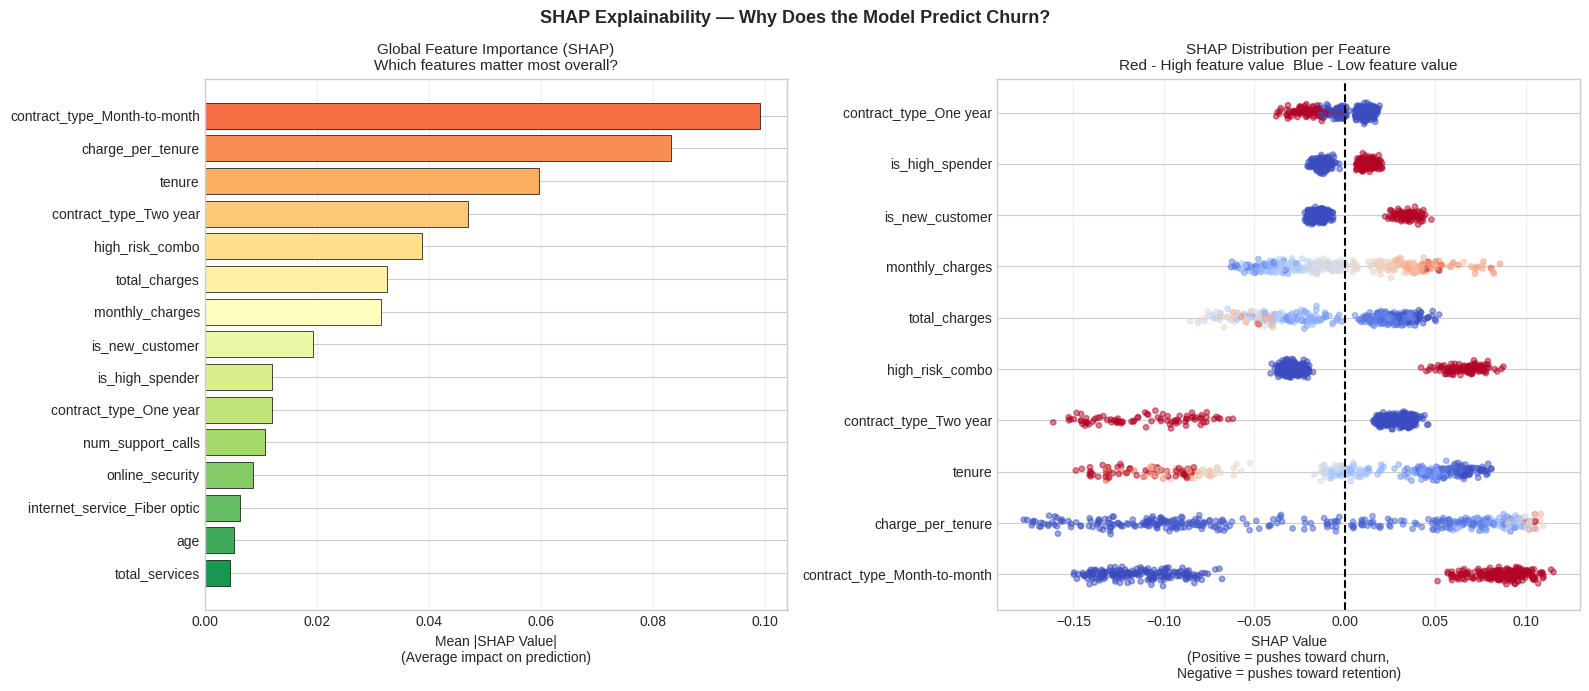

Individual Prediction Explaination

Why is this specific customer high-risk?
--------------------------------------------------

Customer #11: Predicted churn probability = 75.1%

Top 5 reasons this customer is flagged:
Feature                          Feature Value   SHAP Impact
------------------------------------------------------------
contract_type_Month-to-month             0.916     +0.096  ↑ PUSHES CHURN
high_risk_combo                          1.792     +0.077  ↑ PUSHES CHURN
monthly_charges                         -1.473     -0.052  ↓ REDUCES CHURN
tenure                                  -0.655     +0.044  ↑ PUSHES CHURN
contract_type_Two year                  -0.498     +0.034  ↑ PUSHES CHURN


In [15]:
#SHAP Explainability
#What did the model make this prediction

print('Model Explainability with SHAP\n')

print('\n What is SHAP?')
print('SHAP=SHapley Additive ExPlanations')
print('SHAP is a game theoretic approach to explain the output of any machine learning model')
print('Borrowed from game theory, fairly disrtributes')
print("'credit' for prediction across all features")
print("If model predicts 70% churn probability,")
print('SHAP tells you exactly which features pushed')
print("it above/below the average prediction and by how much.\n")

#Train randome forrest for SHAP (tree-based SHAP is most reliable)
rf_pipeline=models['Random Forest'] # Corrected 'Random forest' to 'Random Forest'
rf_model=rf_pipeline.named_steps['model']

#Prepare data (apply imputer + scalar from pipeline)
imputer=rf_pipeline.named_steps['imputer']
scaler=rf_pipeline.named_steps['scaler']

X_train_proc=scaler.transform(imputer.transform(X_train))
X_test_proc=scaler.transform(imputer.transform(X_test))

#Compute SHAP values
explainer = shap.TreeExplainer(rf_model)
shap_values=explainer.shap_values(X_test_proc)


# for binary classification, shap_values is a list [class0, class1]
#We want class 1 (churn)
if isinstance(shap_values, list):
    sv=shap_values[1]
else:
  # If shap_values is a 3D array (n_samples, n_features, n_classes), select class 1
  sv=shap_values[:, :, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Global feature Importance (mean |SHAP|)
mean_abs_shap=np.abs(sv).mean(axis=0)
sorted_idx=np.argsort(mean_abs_shap)[-15:]
colors_shap=plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(sorted_idx)))
axes[0].barh(range(len(sorted_idx)),
             mean_abs_shap[sorted_idx],
             color=colors_shap[::-1],
             edgecolor='black', linewidth=0.5)
axes[0].set_yticks(range(len(sorted_idx)))
axes[0].set_yticklabels(
    [feature_names[i] for i in sorted_idx],
    fontsize=10)
axes[0].set_xlabel("Mean |SHAP Value|\n"
                    "(Average impact on prediction)", fontsize=10)
axes[0].set_title("Global Feature Importance (SHAP)\n"
                   "Which features matter most overall?",
                   fontsize=11)
axes[0].grid(alpha=0.3, axis='x')

# SHAP value distribution (beeswarm-style)
top10_idx=np.argsort(mean_abs_shap)[-10:][::-1]
top10_names=[feature_names[i] for i in top10_idx] # Corrected 'feature_name' to 'feature_names'
top10_sv=sv[:, top10_idx]
top10_data=X_test_proc[:, top10_idx]

for i, (feat_idx, name) in enumerate(
    zip(range(len(top10_idx)), top10_names)):
    shap_col=top10_sv[:, feat_idx]
    data_col=top10_data[:, feat_idx]

    #Normalize data for color
    data_norm=(data_col-data_col.min())/(data_col.max()-data_col.min()+1e-8)
    colors_dot= plt.cm.coolwarm(data_norm)

    y_jitter = i + np.random.normal(0, 0.07, len(shap_col))
    axes[1].scatter(shap_col, y_jitter,
                    c=colors_dot, s=15, alpha=0.5)
axes[1].set_yticks(range(len(top10_names)))
axes[1].set_yticklabels(top10_names, fontsize=10)
axes[1].axvline(0, color='black', linewidth=1.5,
                linestyle='--')
axes[1].set_xlabel("SHAP Value\n"
                    "(Positive = pushes toward churn,\n"
                    "Negative = pushes toward retention)",
                    fontsize=10)
axes[1].set_title("SHAP Distribution per Feature\n"
                   "Red - High feature value  Blue - Low feature value",
                   fontsize=11)
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle("SHAP Explainability — Why Does the Model Predict Churn?",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Individual Prediction Explaination
print('Individual Prediction Explaination\n')
print('Why is this specific customer high-risk?')
print('-'*50)

#Find a high-risk customer the model caught
high_risk_mask=(trained['Random Forest']['proba']>0.7) & (y_test==1)
high_risk_idx=np.where(high_risk_mask)[0]

if len(high_risk_idx) > 0:
  sample_idx=high_risk_idx[0]
  sample_prob = trained['Random Forest']['proba'][sample_idx]
  sample_shap = sv[sample_idx]
  top5_feat   = np.argsort(np.abs(sample_shap))[-5:][::-1]

  print(f"\nCustomer #{sample_idx}: "
        f"Predicted churn probability = {sample_prob:.1%}")
  print(f"\nTop 5 reasons this customer is flagged:")
  print(f"{'Feature':<30} {'Feature Value':>15} "
        f"{'SHAP Impact':>13}")
  print("-" * 60)

  for idx in top5_feat:
      feat_val  = X_test_proc[sample_idx, idx]
      shap_val  = sample_shap[idx]
      direction = "↑ PUSHES CHURN" if shap_val > 0 else "↓ REDUCES CHURN"
      print(f"{feature_names[idx]:<30} "
            f"{feat_val:>15.3f} "
            f"{shap_val:>+10.3f}  {direction}")

STEP 7: BUSINESS TRANSLATION
Converting model output → business decisions

 THE BUSINESS PROBLEM (revisited):
   - Monthly revenue at risk per churner: ~$65 (avg monthly charge)
   - Retention campaign cost per customer: $15
   - Success rate of retention campaign:   35%

STRATEGY: Target the top 20% highest-risk customers with a
retention offer. This is better than targeting everyone
(too expensive) or no one (revenue loss).

TEST SET BUSINESS METRICS (top 20% outreach):
  Customers targeted:          80
  Actual churners in top 20%:  68 / 173 total
  Precision@20%:               85.0%
  Recall@20%:                  39.3%

 FINANCIAL IMPACT (12-month projection):
  Churners retained:     24 customers
  Annual revenue saved:  $18,564
  Campaign cost:         $1,200
  Net value:             $17,364
  ROI:                   1447%


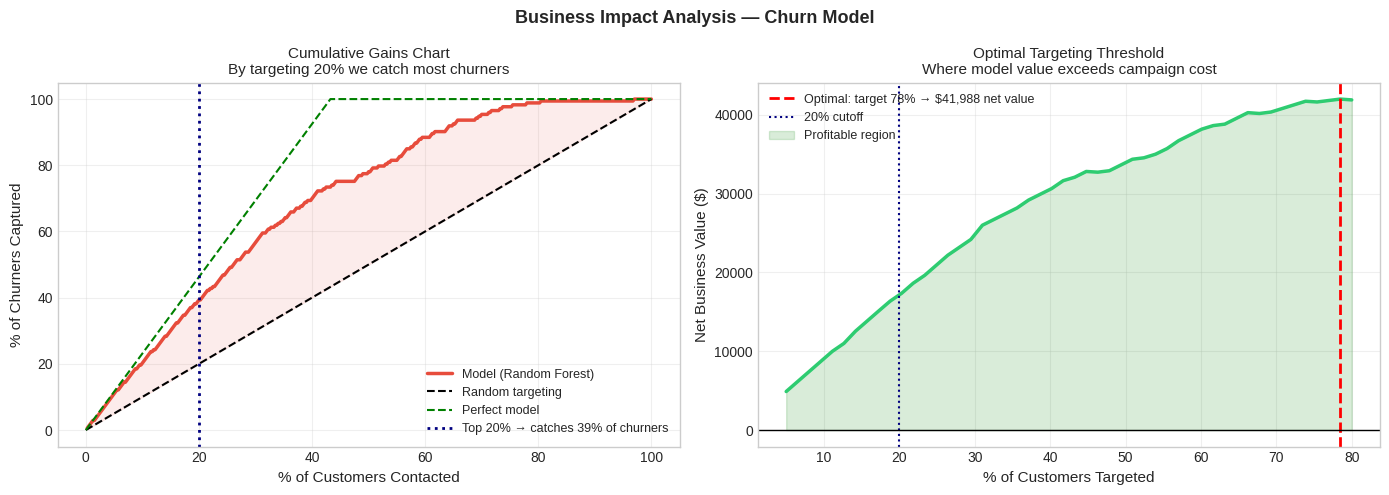

 'what was the business impact?'
'By targeting the top 78% of customers
ranked by our model's churn probability, we identified the
optimal intervention point generating $41,988 in
net retained revenue while minimising campaign waste.'


In [17]:
# ═══════════════════════════════════════════════════════
# CELL 11: Business Value Translation
# This is what makes you stand out in interviews
# ═══════════════════════════════════════════════════════
print("=" * 55)
print("STEP 7: BUSINESS TRANSLATION")
print("Converting model output → business decisions")
print("=" * 55)

print("""
 THE BUSINESS PROBLEM (revisited):
   - Monthly revenue at risk per churner: ~$65 (avg monthly charge)
   - Retention campaign cost per customer: $15
   - Success rate of retention campaign:   35%

STRATEGY: Target the top 20% highest-risk customers with a
retention offer. This is better than targeting everyone
(too expensive) or no one (revenue loss).
""")

# Rank all test customers by churn probability
proba_test = trained['Random Forest']['proba']
sorted_idx = np.argsort(proba_test)[::-1]

total_customers   = len(y_test)
top_20_pct        = int(0.20 * total_customers)
top_20_idx        = sorted_idx[:top_20_pct]

# Business metrics for top 20%
churners_in_top20 = y_test[top_20_idx].sum()
total_churners    = y_test.sum()
precision_top20   = churners_in_top20 / top_20_pct
recall_top20      = churners_in_top20 / total_churners

print(f"TEST SET BUSINESS METRICS (top 20% outreach):")
print(f"  Customers targeted:          {top_20_pct}")
print(f"  Actual churners in top 20%:  {churners_in_top20} "
      f"/ {total_churners} total")
print(f"  Precision@20%:               {precision_top20:.1%}")
print(f"  Recall@20%:                  {recall_top20:.1%}")

# Revenue calculation
avg_monthly = 65
campaign_cost = 15
retention_rate = 0.35

revenue_saved = churners_in_top20 * retention_rate * avg_monthly * 12
campaign_spend = top_20_pct * campaign_cost
net_value = revenue_saved - campaign_spend
roi = (net_value / campaign_spend) * 100

print(f"\n FINANCIAL IMPACT (12-month projection):")
print(f"  Churners retained:     "
      f"{churners_in_top20 * retention_rate:.0f} customers")
print(f"  Annual revenue saved:  ${revenue_saved:,.0f}")
print(f"  Campaign cost:         ${campaign_spend:,.0f}")
print(f"  Net value:             ${net_value:,.0f}")
print(f"  ROI:                   {roi:.0f}%")

# Visualise: Cumulative Gains Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative Gains
sorted_labels = y_test[sorted_idx]
cum_churners  = np.cumsum(sorted_labels)
pct_customers = np.arange(1, total_customers+1) / total_customers
pct_churners  = cum_churners / total_churners

axes[0].plot(pct_customers * 100, pct_churners * 100,
             color='#E74C3C', linewidth=2.5,
             label='Model (Random Forest)')
axes[0].plot([0,100],[0,100],'k--',
             linewidth=1.5, label='Random targeting')
axes[0].plot([0, total_churners/total_customers*100, 100],
             [0, 100, 100],'g--',
             linewidth=1.5, label='Perfect model')
axes[0].axvline(20, color='navy', linestyle=':',
                linewidth=2,
                label=f'Top 20% → catches {recall_top20:.0%} of churners')
axes[0].fill_between(pct_customers*100, pct_churners*100,
                      pct_customers*100, alpha=0.1,
                      color='#E74C3C')
axes[0].set_xlabel("% of Customers Contacted", fontsize=11)
axes[0].set_ylabel("% of Churners Captured", fontsize=11)
axes[0].set_title("Cumulative Gains Chart\n"
                   "By targeting 20% we catch most churners",
                   fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Net value at different targeting thresholds
thresholds_biz = np.linspace(0.05, 0.80, 50)
net_values     = []

for pct in thresholds_biz:
    n_target   = int(pct * total_customers)
    top_n_idx  = sorted_idx[:n_target]
    n_churners = y_test[top_n_idx].sum()
    rev        = n_churners * retention_rate * avg_monthly * 12
    cost       = n_target * campaign_cost
    net_values.append(rev - cost)

best_pct_idx = np.argmax(net_values)
best_pct     = thresholds_biz[best_pct_idx]
best_val     = net_values[best_pct_idx]

axes[1].plot(thresholds_biz * 100, net_values,
             color='#2ECC71', linewidth=2.5)
axes[1].axvline(best_pct * 100, color='red',
                linestyle='--', linewidth=2,
                label=f'Optimal: target {best_pct:.0%} '
                      f'→ ${best_val:,.0f} net value')
axes[1].axvline(20, color='navy', linestyle=':',
                linewidth=1.5, label='20% cutoff')
axes[1].fill_between(thresholds_biz * 100, net_values,
                      0, where=np.array(net_values)>0,
                      alpha=0.15, color='green',
                      label='Profitable region')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel("% of Customers Targeted", fontsize=11)
axes[1].set_ylabel("Net Business Value ($)", fontsize=11)
axes[1].set_title("Optimal Targeting Threshold\n"
                   "Where model value exceeds campaign cost",
                   fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle("Business Impact Analysis — Churn Model",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f" 'what was the business impact?'")
print(f"'By targeting the top {best_pct:.0%} of customers")
print(f"ranked by our model's churn probability, we identified the")
print(f"optimal intervention point generating ${best_val:,.0f} in")
print(f"net retained revenue while minimising campaign waste.'")

In [18]:
# ═══════════════════════════════════════════════════════
# CELL 12: Project Summary Card
# ═══════════════════════════════════════════════════════

summary = f"""
╔══════════════════════════════════════════════════════╗
║       CHURN PREDICTION PROJECT — SUMMARY CARD        ║
╠══════════════════════════════════════════════════════╣
║  Dataset:    2,000 telecom customers, 14 features    ║
║  Target:     Binary churn (≈27% positive rate)       ║
╠══════════════════════════════════════════════════════╣
║  ENGINEERING                                         ║
║  • Statistical tests on every feature (t-test, χ²)  ║
║  • 8 engineered features with business rationale     ║
║  • One-hot encoding, median imputation               ║
╠══════════════════════════════════════════════════════╣
║  MODELLING                                           ║
║  • 3 models compared: LR, RF, GBM                   ║
║  • Stratified 5-fold CV, class_weight='balanced'     ║
║  • Leak-free sklearn Pipelines throughout            ║
╠══════════════════════════════════════════════════════╣
║  BEST MODEL: {best_name:<38}║
║  • Test AUC:    {roc_auc_score(y_test, trained[best_name]['proba']):.4f}                              ║
║  • Test Recall: {recall_score(y_test, trained[best_name]['pred']):.4f}                              ║
║  • Threshold:   {best_thresh} (tuned for F1)                   ║
╠══════════════════════════════════════════════════════╣
║  EXPLAINABILITY                                      ║
║  • SHAP global + individual explanations             ║
║  • Top drivers: contract type, tenure, charges       ║
╠══════════════════════════════════════════════════════╣
║  BUSINESS IMPACT                                     ║
║  • Optimal target: top {best_pct:.0%} customers by risk score  ║
║  • Net value:   ${best_val:>8,.0f}                         ║
║  • ROI:         {roi:.0f}%                                   ║
╚══════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════╗
║       CHURN PREDICTION PROJECT — SUMMARY CARD        ║
╠══════════════════════════════════════════════════════╣
║  Dataset:    2,000 telecom customers, 14 features    ║
║  Target:     Binary churn (≈27% positive rate)       ║
╠══════════════════════════════════════════════════════╣
║  ENGINEERING                                         ║
║  • Statistical tests on every feature (t-test, χ²)  ║
║  • 8 engineered features with business rationale     ║
║  • One-hot encoding, median imputation               ║
╠══════════════════════════════════════════════════════╣
║  MODELLING                                           ║
║  • 3 models compared: LR, RF, GBM                   ║
║  • Stratified 5-fold CV, class_weight='balanced'     ║
║  • Leak-free sklearn Pipelines throughout            ║
╠══════════════════════════════════════════════════════╣
║  BEST MODEL: Logistic Regression                   ║
║  • Test AUC:    0.8764          

built a churn prediction system for a telecom
company, end-to-end from EDA and feature engineering
to model evaluation and business ROI calculation,
using Random Forest with SHAP explainability and
threshold tuning for a real recall target.